In [30]:
import polars as pl
from polars import col as c
import matplotlib.pyplot as plt

In [31]:
lf = pl.scan_parquet('../data/processed/prices.parquet')

## First stats

In [36]:
print('Number of unique tickers, nan, null, infinite: {:}, {:}, {:}, {:}'.format( 
lf.select(
    c('ticker').n_unique()
).collect()[0, 0],
lf.select(
    c('close').is_nan().sum()
).collect()[0, 0],
lf.select(
    c('close').is_null().sum()
).collect()[0, 0],
lf.select(
    c('close').is_infinite().sum()
).collect()[0, 0]
))

Number of unique tickers, nan, null, infinite: 501, 0, 0, 0


In [ ]:
lf.describe()

statistic,ticker,date,open,high,low,close,volume
str,str,str,f64,f64,f64,f64,f64
"""count""","""2917517""","""2917517""",2.917517e6,2.917517e6,2.917517e6,2.917517e6,2.917517e6
"""null_count""","""0""","""0""",0.0,0.0,0.0,0.0,0.0
"""mean""",null,"""2014-01-27 09:58:18.835345""",85.111451,86.11896,84.082275,74.978281,8.5368e6
"""std""",null,null,198.358845,200.748997,195.980598,195.59945,4.7475e7
"""min""","""A""","""2000-01-03""",0.030208,0.030521,0.026979,0.030521,0.0
"""25%""",null,"""2007-09-25""",23.629999,23.95652,23.299999,16.2519,953400.0
"""50%""",null,"""2014-06-23""",45.66,46.189999,45.119999,34.29525,2.23771e6
"""75%""",null,"""2020-08-19""",89.559998,90.540001,88.548111,77.082573,5.4445e6
"""max""","""ZTS""","""2026-07-08""",9914.169922,9964.769531,9794.0,9924.400391,9.2309e9


## Plot prices

In [88]:
# df = lf.filter(
#     pl.col('ticker').is_in(['A', 'AAPL','WYNN', 'WY', 'WELL'])
# ).collect()

tickers = lf.select(
    c('ticker')
    .unique()
    .sample(10)
).collect().to_pandas()

df = lf.filter(
    c('ticker').is_in(tickers.iloc[:, 0].to_list())
).collect()

In [91]:
df

ticker,date,open,high,low,close,volume
str,date,f64,f64,f64,f64,i64
"""AEP""",2000-01-03,32.0,32.0,31.125,10.064169,396900
"""AEP""",2000-01-04,31.375,31.9375,31.375,10.184222,325500
"""AEP""",2000-01-05,31.8125,33.125,31.8125,10.56437,392200
"""AEP""",2000-01-06,32.75,33.6875,32.75,10.624396,433000
"""AEP""",2000-01-07,33.375,33.75,33.0625,10.764462,250500
…,…,…,…,…,…,…
"""TMO""",2026-07-01,504.779999,521.169983,502.869995,513.330017,2220000
"""TMO""",2026-07-02,518.690002,529.150024,511.980011,523.440002,2321800
"""TMO""",2026-07-06,520.0,520.0,506.829987,517.599976,1857600


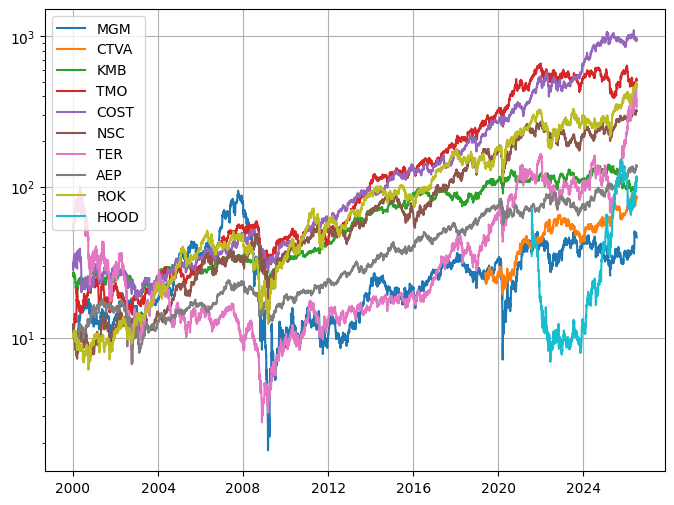

In [ ]:
f, ax = plt.subplots(1, figsize=(8, 6))
plt.yscale('log') 
for ticker in df['ticker'].unique():
    plt.plot(df.filter(c('ticker').is_in([ticker]))['date'], 
             df.filter(c('ticker').is_in([ticker]))['close'], label=ticker)
plt.legend();plt.grid();

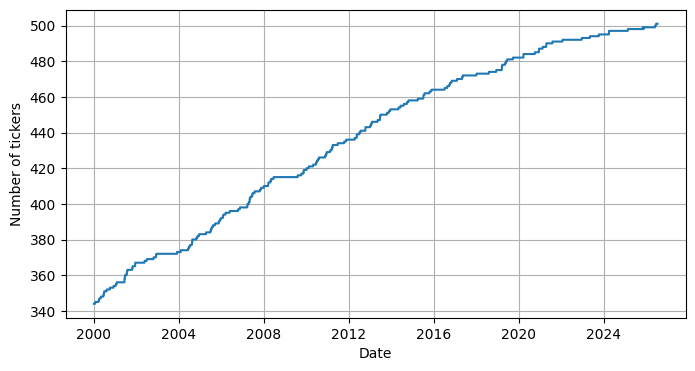

In [ ]:
temp = (
    lf.group_by("date")
    .agg(c('ticker').n_unique())
).collect().sort('date')

f, ax = plt.subplots(1, figsize=(8, 4))
plt.plot(temp['date'], temp['ticker'])
plt.xlabel('Date'); plt.ylabel('Number of tickers'); plt.grid();